# Empirical Momentum Strategies on Real-World Market Data

This notebook implements quantitative momentum strategies using **real historical daily market data** (2007–2024) across 10 core liquid asset classes (Equities, Tech, Small-Caps, Emerging Markets, EAFE, US Treasuries, Corporate Bonds, Gold, Commodities, Real Estate):

1. **Time-Series Momentum (TSMOM / Vol-Scaled Trend Engine)**
2. **Cross-Sectional Momentum (XSMOM / Relative Winner-Loser Ranking)**, with **volatility targeting & crash mitigation** (Barroso & Santa-Clara 2015, Daniel & Moskowitz 2016)
3. **CUSUM Online Changepoint / Regime Filtering**
4. **Empirical Performance Comparison & Equity Curves**
5. **Combined Time-Series + Cross-Sectional Momentum (Multi-Style Expansion)**, with turnover and transaction costs
6. **Statistical significance** of all of the above

**Evaluation window.** No book trades in the first 126 days, every volatility estimate needs 60 observations before it is used, and all tables and charts are scored on one common window, **2008-01-02 to 2024-05-31**. Scoring from the first day of the file instead lets a volatility estimated on two or three returns size the opening positions: TSMOM took roughly 10× leverage in one ETF on the third day of the sample, and that single day moved its full-sample Sharpe from 0.55 to 0.49.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import os

# Load real historical daily price data (2007 - 2024)
csv_path = "real_market_data.csv"
tickers = ["SPY", "QQQ", "IWM", "EEM", "EFA", "TLT", "LQD", "GLD", "DBC", "VNQ"]

if os.path.exists(csv_path):
    df_prices = pd.read_csv(csv_path, index_col=0, parse_dates=True)
else:
    df_prices = yf.download(tickers, start="2007-01-01", end="2024-06-01")["Close"].dropna()
    df_prices.to_csv(csv_path)

df_returns = df_prices.pct_change().fillna(0)
start_str = df_prices.index[0].strftime("%Y-%m-%d")
end_str = df_prices.index[-1].strftime("%Y-%m-%d")
print(f"Loaded Real-World Price Data from {start_str} to {end_str}")
print(f"Asset Universe ({df_prices.shape[1]} Tickers): {list(df_prices.columns)}")
df_prices.tail(3)


Loaded Real-World Price Data from 2007-01-03 to 2024-05-31
Asset Universe (10 Tickers): ['DBC', 'EEM', 'EFA', 'GLD', 'IWM', 'LQD', 'QQQ', 'SPY', 'TLT', 'VNQ']


,DBC,EEM,EFA,GLD,IWM,LQD,QQQ,SPY,TLT,VNQ
Date,,,,,,,,,,
2024-05-29,21.757105,40.149223,73.486862,216.160004,196.725311,94.836601,450.516602,511.011749,80.116074,73.085548
2024-05-30,21.472399,40.035378,74.104340,216.570007,198.593964,95.419418,445.690002,507.622009,80.890434,74.156471
2024-05-31,21.371374,39.646412,74.813950,215.300003,200.267990,95.840820,444.860931,512.245361,81.439636,75.545021


## 1. Time-Series Momentum (TSMOM / Volatility-Scaled Trend Engine)

TSMOM evaluates each asset individually against its own historical moving average trend.

**Signal** — sign of a fast/slow EWMA crossover (spans of 32 and 96 days):

$$s_{i,t} = \operatorname{sign}\!\left(\text{EWMA}_{\text{fast}}(P_{i,t}) - \text{EWMA}_{\text{slow}}(P_{i,t})\right)$$

**Position** — the signal scaled by inverse volatility so each asset contributes a comparable risk budget, where $\hat{\sigma}_{i,t}$ is the annualized 60-day EWMA volatility of returns and $\sigma_{\text{target}} = 15\%$:

$$w_{i,t} = \frac{\sigma_{\text{target}}}{\hat{\sigma}_{i,t}} \cdot s_{i,t}$$

**Portfolio return** — equal-weighted across the $N$ assets, with positions lagged one day so the signal is only traded on information available at $t-1$. The volatility estimate is only used once it has 60 observations, and no position is taken during the first 126 days:

$$r^{\text{TSMOM}}_{t} = \frac{1}{N} \sum_{i=1}^{N} w_{i,t-1} \, r_{i,t}$$


In [2]:
WARMUP = 126            # days before any book may trade (= the XSMOM lookback)
EVAL_START = "2008-01-02"  # every table and chart below is scored from here, on one common window


def sharpe(r: pd.Series) -> float:
    return np.sqrt(252) * r.mean() / r.std()


def ev(r: pd.Series) -> pd.Series:
    """Restrict a return series to the common evaluation window."""
    r = r.loc[EVAL_START:]
    assert r.notna().all(), "series is not fully warmed up at EVAL_START"
    return r


class TimeSeriesMomentum:
    def __init__(self, fast=32, slow=96, vol_span=60, target_vol=0.15, warmup=WARMUP):
        self.fast = fast
        self.slow = slow
        self.vol_span = vol_span
        self.target_vol = target_vol
        self.warmup = warmup

    def run(self, df_prices: pd.DataFrame) -> pd.Series:
        returns = df_prices.pct_change()
        fast_ma = df_prices.ewm(span=self.fast, adjust=False).mean()
        slow_ma = df_prices.ewm(span=self.slow, adjust=False).mean()
        signal = np.sign(fast_ma - slow_ma)

        # Historical annualized asset volatility. min_periods matters: an EWMA std on
        # two or three observations can be near zero, and sizing off it put ~10x
        # leverage on a single ETF on the third day of the sample.
        ann_vol = (returns.ewm(span=self.vol_span, adjust=False, min_periods=self.vol_span).std() * np.sqrt(252)).clip(lower=0.01)
        positions = signal * (self.target_vol / ann_vol)
        positions.iloc[:self.warmup] = np.nan
        # Weights actually held on day t (decided at t-1), as a fraction of NAV
        self.held_ = positions.shift(1) / df_prices.shape[1]
        return (self.held_ * returns).sum(axis=1, min_count=1)

tsmom_engine = TimeSeriesMomentum()
tsmom_returns = tsmom_engine.run(df_prices)
print(f"First TSMOM trading day: {tsmom_returns.first_valid_index():%Y-%m-%d}")
print(f"Multi-Asset TSMOM Sharpe Ratio ({EVAL_START[:4]}-2024): {sharpe(ev(tsmom_returns)):.2f}")

First TSMOM trading day: 2007-07-06
Multi-Asset TSMOM Sharpe Ratio (2008-2024): 0.56


## 2. Cross-Sectional Momentum (XSMOM) & Volatility Scaling

XSMOM ranks assets relative to one another across the universe, going long the top $k = 3$ and short the bottom $k = 3$ names. With a 10-asset universe this is a top/bottom tercile split rather than a decile one. The book is dollar-neutral and gross-normalized to 1:

$$w_{i,t} = \frac{\mathbf{1}\{\text{rank}_{i,t} \le k\} - \mathbf{1}\{\text{rank}_{i,t} > N - k\}}{2k}, \qquad r^{\text{raw}}_{t} = \sum_{i=1}^{N} w_{i,t-1} \, r_{i,t}$$

- **Unscaled XSMOM**: ranks strictly by the raw 6-month return $r_{i,t-126:t} = P_{i,t} / P_{i,t-126} - 1$. High-beta distressed assets get selected into the short leg, leading to momentum crashes during V-shaped rebounds (e.g. 2009).
- **Vol-Scaled Ranking & Target Volatility**: ranks by the risk-adjusted return $r_{i,t-126:t} / \hat{\sigma}_{i,t}$ (with $\hat{\sigma}_{i,t}$ the annualized 60-day rolling volatility) and scales overall portfolio leverage to hold strategy risk at the target:

$$L_{t} = \frac{\sigma_{\text{target}}}{\hat{\sigma}_{\text{strat},t-1}}, \qquad r^{\text{XSMOM}}_{t} = L_{t} \, r^{\text{raw}}_{t}$$

Here $\hat{\sigma}_{\text{strat},t}$ is the annualized 60-day EWMA volatility of the *unlevered* strategy return, lagged one day. This is the Barroso & Santa-Clara (2015) and Daniel & Moskowitz (2016) crash-mitigation mechanism: realized volatility spikes ahead of momentum crashes, so leverage is cut before the drawdown rather than after it.


In [3]:
class CrossSectionalMomentum:
    def __init__(self, lookback=126, top_k=3, target_vol=0.15, vol_scaled=True):
        self.lookback = lookback
        self.top_k = top_k
        self.target_vol = target_vol
        self.vol_scaled = vol_scaled

    def run(self, df_prices: pd.DataFrame) -> pd.Series:
        returns = df_prices.pct_change()
        past_ret = df_prices.pct_change(self.lookback)
        ann_vol = (returns.rolling(60).std() * np.sqrt(252)).clip(lower=0.01)

        # Ranking criteria
        score = past_ret / ann_vol if self.vol_scaled else past_ret
        ranks = score.rank(axis=1, ascending=False)

        long_mask = (ranks <= self.top_k).astype(float)
        short_mask = (ranks > (df_prices.shape[1] - self.top_k)).astype(float)
        # No book until every name has a full lookback (NaN, not a flat zero-return book)
        weights = ((long_mask - short_mask) / (2 * self.top_k)).where(score.notna().all(axis=1))
        self.held_ = weights.shift(1)
        raw_strat_ret = (self.held_ * returns).sum(axis=1, min_count=1)

        if self.vol_scaled:
            # Portfolio-level volatility targeting (Barroso & Santa-Clara 2015, Daniel & Moskowitz 2016).
            # min_periods: the leverage is undefined until 60 real strategy returns exist.
            strat_vol = (raw_strat_ret.ewm(span=60, adjust=False, min_periods=60).std() * np.sqrt(252)).clip(lower=0.02)
            leverage = (self.target_vol / strat_vol).shift(1)
            self.held_ = self.held_.mul(leverage, axis=0)
            return raw_strat_ret * leverage
        return raw_strat_ret

xs_unscaled_engine = CrossSectionalMomentum(vol_scaled=False)
xs_scaled_engine = CrossSectionalMomentum(vol_scaled=True)
xsmom_unscaled = xs_unscaled_engine.run(df_prices)
xsmom_scaled = xs_scaled_engine.run(df_prices)

print(f"First trading day: unscaled {xsmom_unscaled.first_valid_index():%Y-%m-%d}, vol-scaled {xsmom_scaled.first_valid_index():%Y-%m-%d}")
print(f"Unscaled XSMOM Sharpe: {sharpe(ev(xsmom_unscaled)):.2f}")
print(f"Vol-Scaled XSMOM Sharpe: {sharpe(ev(xsmom_scaled)):.2f}")

First trading day: unscaled 2007-07-06, vol-scaled 2007-10-01
Unscaled XSMOM Sharpe: 0.05
Vol-Scaled XSMOM Sharpe: 0.32


## 3. CUSUM Online Changepoint / Regime Filtering

An online two-sided CUSUM filter detects structural trend-break regimes (e.g. the 2008 Lehman collapse, the 2020 COVID panic) so that exposure can be scaled down during regime shifts.

The strategy return is standardized using **expanding moments lagged by one day**, so the filter only ever conditions on information already realized:

$$z_t = \frac{r_t - \hat{\mu}_{t-1}}{\hat{\sigma}_{t-1}}, \qquad \hat{\mu}_{t-1} = \frac{1}{t-1}\sum_{u=1}^{t-1} r_u, \qquad \hat{\sigma}^{2}_{t-1} = \frac{1}{t-2}\sum_{u=1}^{t-1}\left(r_u - \hat{\mu}_{t-1}\right)^{2}$$

The moments require a $126$-day warmup before they are defined (which makes the filter live from the first week of 2008, the start of the evaluation window); until then $z_t = 0$ and the filter stays dormant rather than firing on a noisy estimate. From the standardized series the filter accumulates one-sided sums with slack parameter $\kappa = 0.5$:

$$S^{+}_{t} = \max\left(0, \; S^{+}_{t-1} + z_t - \kappa\right), \qquad S^{-}_{t} = \max\left(0, \; S^{-}_{t-1} - z_t - \kappa\right)$$

The slack $\kappa$ makes the sums decay under normal conditions, so only *persistent* drift accumulates. A changepoint is flagged when either sum breaches the threshold $h = 2.5$; both sums then reset to zero and exposure is cut to 25% for that day:

$$\lambda_t = \begin{cases} 0.25 & \text{if } S^{+}_{t} > h \ \text{ or } \ S^{-}_{t} > h \\ 1 & \text{otherwise} \end{cases}, \qquad r^{\text{CPD}}_{t} = \lambda_{t-1} \, r_{t}$$

Because $\lambda$ is applied with a one-day lag and both moments are estimated out-of-sample, the resulting Sharpe ratio is a legitimate backtest figure. The filter fires on 70 days, clustered in the episodes it is meant to catch: 31 in 2008, 13 in the 2011 euro-crisis selloff, and 15 in the 2020 COVID panic.

One property to be aware of: an expanding window grows progressively less sensitive, since each new observation moves $\hat{\mu}$ and $\hat{\sigma}$ less than the last. Swapping in a 2-year rolling window roughly doubles the detection count to 149 and scatters them through calm years, which *lowers* the filtered Sharpe (0.04 vs. 0.10) by de-leveraging into recoveries.

The sensitivity block printed below the result is the more important read. Across thresholds $h$ from 2.0 to 4.0 the filtered Sharpe runs from 0.09 to 0.16 against 0.05 unfiltered, and it is not monotone in $h$. The filter never hurts on this sample, and no setting moves the Sharpe by more than about a tenth.


In [4]:
def cusum_regime_filter(series: pd.Series, threshold=2.5, warmup=126, window=None) -> pd.Series:
    # Causal standardization: moments lagged one day, so z_t only uses returns up to
    # t-1. Expanding by default; `window` switches to a rolling estimate. Before
    # `warmup` observations the moments are undefined, so z = 0 and the filter is dormant.
    roll = series.expanding(min_periods=warmup) if window is None else series.rolling(window, min_periods=warmup)
    mu = roll.mean().shift(1)
    sigma = roll.std().shift(1)
    z = ((series - mu) / (sigma + 1e-6)).fillna(0.0)
    pos_sum, neg_sum = 0.0, 0.0
    weights = np.ones(len(series))

    for i in range(1, len(series)):
        pos_sum = max(0.0, pos_sum + z.iloc[i] - 0.5)
        neg_sum = max(0.0, neg_sum - z.iloc[i] - 0.5)
        if pos_sum > threshold or neg_sum > threshold:
            # De-leverage on the detection day only; the reset below means the
            # filter must re-accumulate before it fires again
            weights[i] = 0.25
            pos_sum, neg_sum = 0.0, 0.0

    return pd.Series(weights, index=series.index)

cpd_weights = cusum_regime_filter(xsmom_unscaled)
xsmom_cpd_returns = xsmom_unscaled * cpd_weights.shift(1)
cpd_held = xs_unscaled_engine.held_.mul(cpd_weights.shift(1), axis=0)

hits = cpd_weights.loc[EVAL_START:] < 1
print(f"Filter active from {xsmom_unscaled.dropna().index[126]:%Y-%m-%d}")
print(f"CPD-Filtered XSMOM Sharpe: {sharpe(ev(xsmom_cpd_returns)):.2f}  (unfiltered {sharpe(ev(xsmom_unscaled)):.2f})")
print(f"Detections: {hits.sum()} days; by year: {hits.groupby(hits.index.year).sum().loc[lambda s: s > 0].to_dict()}")

# Sensitivity: the same filter under other standardization windows and thresholds
print("\nSensitivity of the filtered Sharpe")
for label, kwargs in {
    "expanding, h=2.5 (used)": {},
    "2y rolling, h=2.5": {"window": 504},
    "expanding, h=2.0": {"threshold": 2.0},
    "expanding, h=3.0": {"threshold": 3.0},
    "expanding, h=4.0": {"threshold": 4.0},
}.items():
    w = cusum_regime_filter(xsmom_unscaled, **kwargs)
    print(f"  {label:26} hits={int((w.loc[EVAL_START:] < 1).sum()):4d}  Sharpe={sharpe(ev(xsmom_unscaled * w.shift(1))):.2f}")

Filter active from 2008-01-04
CPD-Filtered XSMOM Sharpe: 0.10  (unfiltered 0.05)
Detections: 70 days; by year: {2008: 31, 2009: 4, 2011: 13, 2015: 1, 2016: 1, 2018: 1, 2020: 15, 2022: 4}

Sensitivity of the filtered Sharpe
  expanding, h=2.5 (used)    hits=  70  Sharpe=0.10
  2y rolling, h=2.5          hits= 149  Sharpe=0.04
  expanding, h=2.0           hits=  91  Sharpe=0.09
  expanding, h=3.0           hits=  48  Sharpe=0.09
  expanding, h=4.0           hits=  28  Sharpe=0.16


## 4. Empirical Performance Comparison & Equity Curves (2008–2024)

All Sharpe ratios are annualized from daily returns with a zero risk-free rate, $\text{SR} = \sqrt{252} \cdot \bar{r} / \hat{\sigma}(r)$, and the curves show gross cumulative wealth $\prod_{t}(1 + r_t)$ on a log scale with no transaction costs or financing charges (costs are added at the end of section 5). All series start on 2008-01-02.


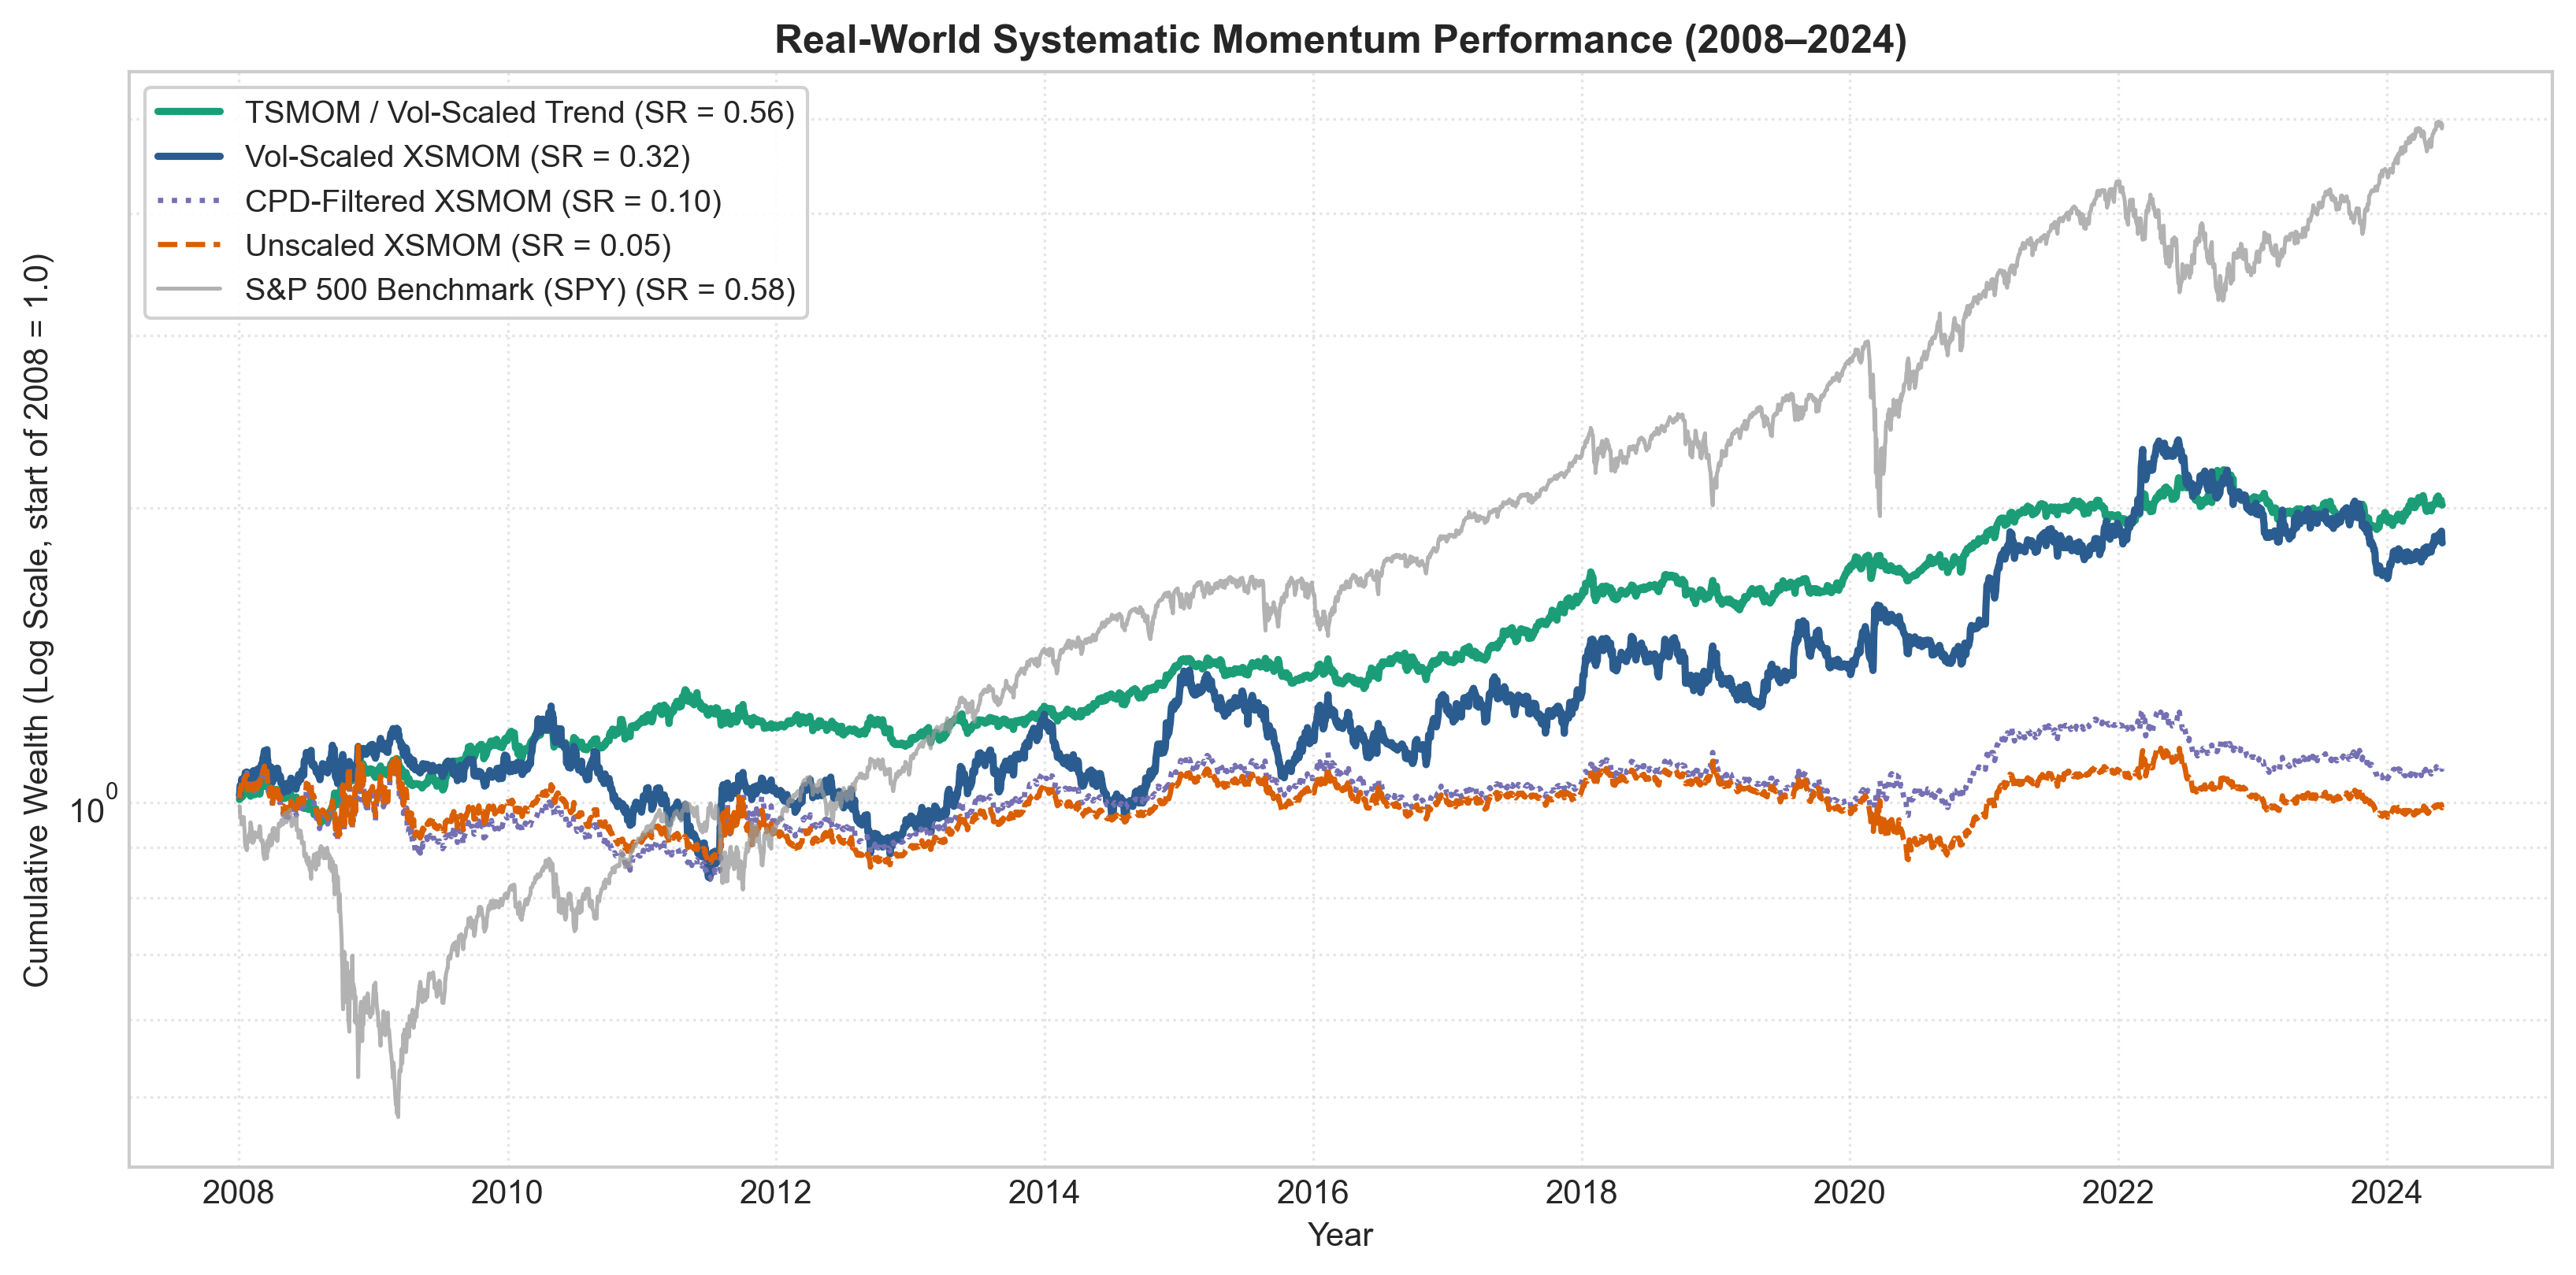

In [5]:
spy_returns = ev(df_returns["SPY"])
sharpe_spy = sharpe(spy_returns)


def wealth(r: pd.Series) -> pd.Series:
    return (1 + ev(r)).cumprod()


plt.figure(figsize=(11, 5.5), dpi=300)
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")

plt.plot(wealth(tsmom_returns), label=f"TSMOM / Vol-Scaled Trend (SR = {sharpe(ev(tsmom_returns)):.2f})", color="#1b9e77", lw=2.2)
plt.plot(wealth(xsmom_scaled), label=f"Vol-Scaled XSMOM (SR = {sharpe(ev(xsmom_scaled)):.2f})", color="#2b5c8f", lw=2.2)
plt.plot(wealth(xsmom_cpd_returns), label=f"CPD-Filtered XSMOM (SR = {sharpe(ev(xsmom_cpd_returns)):.2f})", color="#7570b3", lw=1.6, ls=":")
plt.plot(wealth(xsmom_unscaled), label=f"Unscaled XSMOM (SR = {sharpe(ev(xsmom_unscaled)):.2f})", color="#d95f02", lw=1.6, ls="--")
plt.plot(wealth(df_returns["SPY"]), label=f"S&P 500 Benchmark (SPY) (SR = {sharpe_spy:.2f})", color="#999999", lw=1.2, alpha=0.75)

plt.yscale("log")
plt.title("Real-World Systematic Momentum Performance (2008–2024)", fontsize=12, fontweight="bold")
plt.xlabel("Year", fontsize=10)
plt.ylabel("Cumulative Wealth (Log Scale, start of 2008 = 1.0)", fontsize=10)
plt.legend(loc="upper left", frameon=True, facecolor="white", framealpha=0.9, fontsize=9.5)
plt.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()

### Risk & Drawdown Characteristics

The Sharpe ratio treats upside and downside dispersion symmetrically and says nothing about how long a loss persists, so the table below adds:

- **Annualized return** — geometric, so it reflects the compounding actually shown in the equity curves: $\text{CAGR} = W_T^{252/T} - 1$.
- **Sortino ratio** — replaces total volatility with downside deviation against a zero minimum acceptable return, so a strategy is not penalized for upside convexity (the property trend-following is bought for):

$$\text{Sortino} = \frac{\sqrt{252} \, \bar{r}}{\sigma_{\text{down}}}, \qquad \sigma_{\text{down}} = \sqrt{\frac{1}{T} \sum_{t=1}^{T} \min(r_t, 0)^{2}}$$

- **Max drawdown** — worst peak-to-trough decline in cumulative wealth:

$$\text{MDD} = \min_{t} \left( \frac{W_t}{\max_{u \le t} W_u} - 1 \right)$$

- **Calmar ratio** — geometric annualized return per unit of worst-case loss, $\text{CAGR} / |\text{MDD}|$. This is the metric a leveraged allocator cares about, since max drawdown sets the capital needed to survive the strategy.
- **Drawdown length** — an episode runs from the day wealth first falls below a prior high-water mark until the day it regains it. Reported as the count, mean and longest episode in trading days, alongside the share of all days spent underwater.

Three conventions worth noting.

The $\sigma_{\text{down}}$ denominator averages over *all* $T$ observations rather than only the negative ones, which keeps it on the same scale as the volatility in the Sharpe denominator. Dividing by the count of negative days instead would inflate Sortino for strategies that lose rarely but heavily — the opposite of the intended reading.

Drawdown-length statistics count only episodes that trough below **–5%**. Without a depth filter the figures are meaningless: any day that is not an all-time high opens an "episode", so the average is dominated by thousands of one-day dips of a few basis points. The `% Underwater` column is reported unfiltered, which is why it sits near 90% for every series — markets and strategies alike make new highs on only a small minority of days.

The final episode is right-censored whenever a strategy ends the sample below its high-water mark, so average and longest length are understated for those series.

In [6]:
TRADING_DAYS = 252


def performance_stats(returns: pd.Series, depth=0.05) -> dict:
    wealth = (1 + returns).cumprod()
    peak = wealth.cummax()
    drawdown = wealth / peak - 1

    cagr = wealth.iloc[-1] ** (TRADING_DAYS / len(returns)) - 1
    max_dd = drawdown.min()
    # Daily downside deviation (MAR = 0), annualized inside the Sortino ratio below
    downside_dev = np.sqrt((returns.clip(upper=0) ** 2).mean())

    # Underwater episodes: consecutive runs of days below the prior high-water mark.
    # Only episodes troughing below -`depth` count, otherwise the statistics are
    # swamped by the thousands of 1-day dips that any non-new-high day creates.
    underwater = wealth < peak
    runs = underwater.ne(underwater.shift()).cumsum()
    lengths = underwater.groupby(runs).sum()
    material = lengths[drawdown.groupby(runs).min() <= -depth]

    return {
        "Ann. Return": cagr,
        "Ann. Vol": returns.std() * np.sqrt(TRADING_DAYS),
        "Sharpe": np.sqrt(TRADING_DAYS) * returns.mean() / returns.std(),
        "Sortino": np.sqrt(TRADING_DAYS) * returns.mean() / downside_dev,
        "Max DD": max_dd,
        "Calmar": cagr / abs(max_dd),
        f"DD > {depth:.0%}": len(material),
        "Avg DD (days)": material.mean() if len(material) else 0.0,
        "Longest DD (days)": material.max() if len(material) else 0.0,
        "% Underwater": underwater.mean(),
    }


def stats_table(strategies: dict) -> pd.DataFrame:
    table = pd.DataFrame([performance_stats(r) for r in strategies.values()], index=list(strategies))
    formatted = table.copy()
    for col in ("Ann. Return", "Ann. Vol", "Max DD", "% Underwater"):
        formatted[col] = table[col].map(lambda v: f"{v * 100:.1f}%")
    for col in ("Sharpe", "Sortino", "Calmar"):
        formatted[col] = table[col].map(lambda v: f"{v:.2f}")
    for col in ("Avg DD (days)", "Longest DD (days)"):
        formatted[col] = table[col].map(lambda v: f"{v:.0f}")
    return formatted.T


# Every series is cut to the common evaluation window, so no row of the table is
# flattered or penalized by a different start date.
strategy_returns = {
    name: ev(r)
    for name, r in {
        "TSMOM / Vol-Scaled Trend": tsmom_returns,
        "Vol-Scaled XSMOM": xsmom_scaled,
        "CPD-Filtered XSMOM": xsmom_cpd_returns,
        "Unscaled XSMOM": xsmom_unscaled,
        "S&P 500 (SPY)": df_returns["SPY"],
    }.items()
}

stats_table(strategy_returns)

,TSMOM / Vol-Scaled Trend,Vol-Scaled XSMOM,CPD-Filtered XSMOM,Unscaled XSMOM,S&P 500 (SPY)
Ann. Return,4.4%,3.8%,0.5%,-0.1%,10.2%
Ann. Vol,8.2%,15.4%,11.1%,11.9%,20.2%
Sharpe,0.56,0.32,0.10,0.05,0.58
Sortino,0.78,0.46,0.14,0.07,0.82
Max DD,-13.1%,-33.3%,-24.6%,-25.3%,-51.9%
Calmar,0.33,0.11,0.02,-0.00,0.20
DD > 5%,12,15,5,3,18
Avg DD (days),245,254,751,1361,144
Longest DD (days),839,1165,1476,3906,835
% Underwater,94.1%,97.4%,98.8%,99.7%,88.3%


## 5. Combined Time-Series + Cross-Sectional Momentum (Multi-Style Expansion)

Following Baz et al. (2015), combining Time-Series Momentum (directional trend) and Cross-Sectional Momentum (relative winner-loser ranking) is meant to exploit a low pairwise correlation between the two styles to smooth out drawdowns and enhance overall risk-adjusted returns.

Each sleeve is first scaled to the common volatility target, blended at equal risk weight, and the blend is then re-scaled to the same target:

$$r^{\text{combo}}_{t} = \frac{\sigma_{\text{target}}}{\hat{\sigma}_{\text{combo},t-1}} \left( \tfrac{1}{2} r^{\text{TSMOM}}_{t} + \tfrac{1}{2} r^{\text{XSMOM}}_{t} \right)$$

Because the two sleeves are imperfectly correlated ($\rho < 1$), the blended volatility obeys

$$\hat{\sigma}_{\text{combo}} = \tfrac{1}{2}\sqrt{\hat{\sigma}^{2}_{\text{TS}} + \hat{\sigma}^{2}_{\text{XS}} + 2\rho \, \hat{\sigma}_{\text{TS}} \hat{\sigma}_{\text{XS}}} \; < \; \tfrac{1}{2}\left(\hat{\sigma}_{\text{TS}} + \hat{\sigma}_{\text{XS}}\right)$$

so the final vol-targeting step mechanically levers the combination up relative to its individual sleeves, converting the diversification benefit into return rather than just lower risk.

On this universe the mechanism has little to work with. The two sleeves are built from the same ten price series and correlate at 0.45, and the cross-sectional sleeve has the lower Sharpe (0.32 vs. 0.61 for vol-targeted TSMOM). The blend comes out at 0.54: below TSMOM alone, with a deeper drawdown (−28% vs. −20%). Diversification only pays when the added sleeve is either good or nearly uncorrelated, and here it is neither.

First combined trading day: 2007-12-26
Sleeve correlation (TS vs XS): 0.45
Combined TS + XS Momentum Sharpe Ratio: 0.54


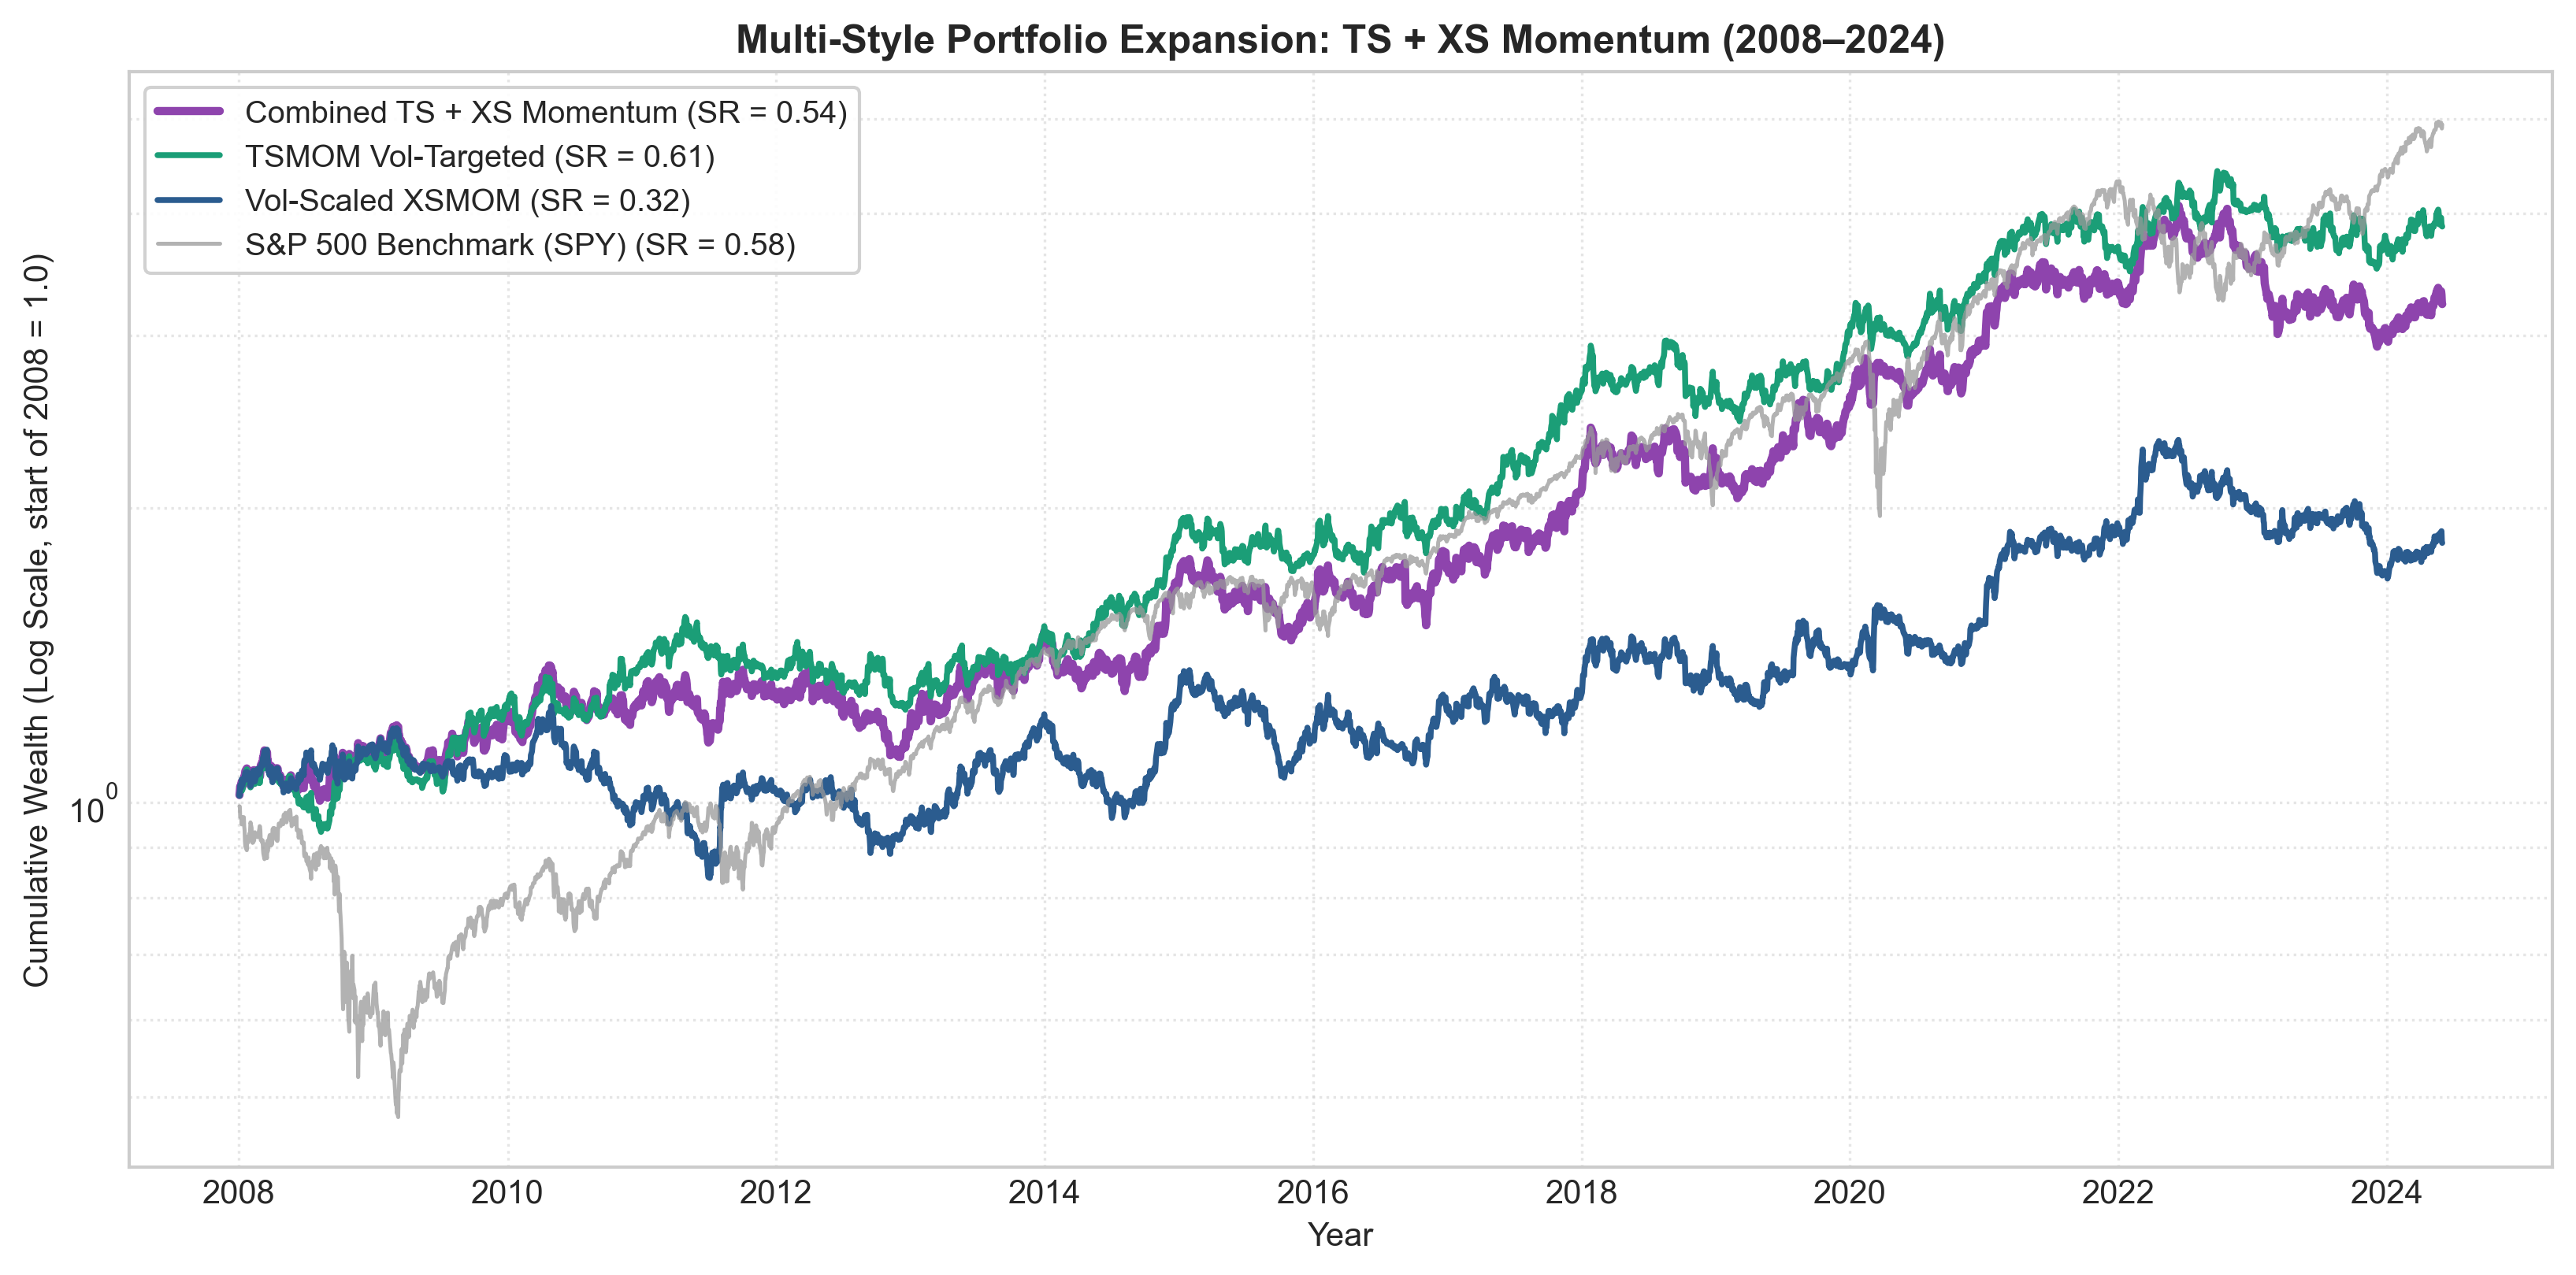

,Combined TS + XS Momentum,TSMOM Vol-Targeted,Vol-Scaled XSMOM,S&P 500 (SPY)
Ann. Return,7.4%,8.6%,3.8%,10.2%
Ann. Vol,15.4%,15.4%,15.4%,20.2%
Sharpe,0.54,0.61,0.32,0.58
Sortino,0.76,0.85,0.46,0.82
Max DD,-28.2%,-20.5%,-33.3%,-51.9%
Calmar,0.26,0.42,0.11,0.20
DD > 5%,18,24,15,18
Avg DD (days),194,138,254,144
Longest DD (days),804,771,1165,835
% Underwater,94.9%,94.2%,97.4%,88.3%


In [7]:
# Combine Vol-Scaled TSMOM and Vol-Scaled XSMOM
tsmom_vol = (tsmom_returns.ewm(span=60, adjust=False, min_periods=60).std() * np.sqrt(252)).clip(lower=0.02)
tsmom_lev = (0.15 / tsmom_vol).shift(1)
tsmom_scaled = tsmom_returns * tsmom_lev
tsmom_scaled_held = tsmom_engine.held_.mul(tsmom_lev, axis=0)

# Equal Volatility Risk Parity Combo
combined_raw = 0.5 * tsmom_scaled + 0.5 * xsmom_scaled
combined_vol = (combined_raw.ewm(span=60, adjust=False, min_periods=60).std() * np.sqrt(252)).clip(lower=0.02)
combined_lev = (0.15 / combined_vol).shift(1)
combined_ts_xs = combined_raw * combined_lev
combined_held = (0.5 * tsmom_scaled_held + 0.5 * xs_scaled_engine.held_).mul(combined_lev, axis=0)

sr_comb = sharpe(ev(combined_ts_xs))
print(f"First combined trading day: {combined_ts_xs.first_valid_index():%Y-%m-%d}")
print(f"Sleeve correlation (TS vs XS): {ev(tsmom_scaled).corr(ev(xsmom_scaled)):.2f}")
print(f"Combined TS + XS Momentum Sharpe Ratio: {sr_comb:.2f}")

# Plot Updated Multi-Style Comparison
plt.figure(figsize=(11, 5.5), dpi=300)
plt.plot(wealth(combined_ts_xs), label=f"Combined TS + XS Momentum (SR = {sr_comb:.2f})", color="#8e44ad", lw=2.5)
plt.plot(wealth(tsmom_scaled), label=f"TSMOM Vol-Targeted (SR = {sharpe(ev(tsmom_scaled)):.2f})", color="#1b9e77", lw=1.8)
plt.plot(wealth(xsmom_scaled), label=f"Vol-Scaled XSMOM (SR = {sharpe(ev(xsmom_scaled)):.2f})", color="#2b5c8f", lw=1.8)
plt.plot(wealth(df_returns["SPY"]), label=f"S&P 500 Benchmark (SPY) (SR = {sharpe_spy:.2f})", color="#999999", lw=1.2, alpha=0.75)
plt.yscale("log")
plt.title("Multi-Style Portfolio Expansion: TS + XS Momentum (2008–2024)", fontsize=12, fontweight="bold")
plt.xlabel("Year", fontsize=10)
plt.ylabel("Cumulative Wealth (Log Scale, start of 2008 = 1.0)", fontsize=10)
plt.legend(loc="upper left", frameon=True, facecolor="white", framealpha=0.9, fontsize=9.5)
plt.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()

stats_table({
    "Combined TS + XS Momentum": ev(combined_ts_xs),
    "TSMOM Vol-Targeted": ev(tsmom_scaled),
    "Vol-Scaled XSMOM": ev(xsmom_scaled),
    "S&P 500 (SPY)": spy_returns,
})

### Turnover and transaction costs

Everything above is gross. The books are re-formed every day, so what a gross Sharpe is worth depends on how much they trade. With $h_{i,t}$ the weight held in asset $i$ on day $t$ as a fraction of NAV (signal, vol scaling and any portfolio-level leverage included), one-way turnover and the net return at a cost of $c$ per unit traded are

$$\tau_t = \sum_{i=1}^{N} \left| h_{i,t} - h_{i,t-1} \right|, \qquad r^{\text{net}}_t = r_t - c \, \tau_t$$

Weight drift between rebalances is ignored, which slightly understates turnover. The break-even cost $c^{*} = \bar{r} / \bar{\tau}$ is the level at which the average return is zero. For scale: these ten ETFs quote at roughly 1 bp or less of half-spread for SPY/QQQ/IWM and 1–3 bp for the others, before market impact and short-borrow fees. SPY held passively has no turnover, so its row in the tables above does not move.

The table separates the books cleanly. TSMOM turns over about 10× NAV a year and breaks even at roughly 47 bp, so realistic ETF costs take a few hundredths off its Sharpe. Every cross-sectional book re-ranks daily and trades 36–81× NAV a year: unscaled XSMOM breaks even at 1.8 bp and the vol-scaled version at 6 bp, which is inside the bid–ask spread of half this universe. The combined book inherits that turnover and drops from 0.54 to 0.31 at 5 bp. A weekly or monthly rebalance would be the first thing to change before taking any XSMOM number here seriously.

In [8]:
def cost_table(books: dict, bps_grid=(0, 2, 5, 10)) -> pd.DataFrame:
    rows = {}
    for name, (gross, held) in books.items():
        gross = ev(gross)
        turnover = held.diff().abs().sum(axis=1).loc[gross.index]
        row = {
            "Avg gross leverage": f"{held.abs().sum(axis=1).loc[gross.index].mean():.2f}",
            "Turnover (x NAV / yr)": f"{252 * turnover.mean():.1f}",
        }
        for bps in bps_grid:
            row[f"Sharpe @ {bps} bp"] = f"{sharpe(gross - turnover * bps / 1e4):.2f}"
        row["Break-even cost (bp)"] = f"{1e4 * gross.mean() / turnover.mean():.1f}"
        rows[name] = row
    return pd.DataFrame(rows)


cost_table({
    "Combined TS + XS Momentum": (combined_ts_xs, combined_held),
    "TSMOM / Vol-Scaled Trend": (tsmom_returns, tsmom_engine.held_),
    "Vol-Scaled XSMOM": (xsmom_scaled, xs_scaled_engine.held_),
    "CPD-Filtered XSMOM": (xsmom_cpd_returns, cpd_held),
    "Unscaled XSMOM": (xsmom_unscaled, xs_unscaled_engine.held_),
})

,Combined TS + XS Momentum,TSMOM / Vol-Scaled Trend,Vol-Scaled XSMOM,CPD-Filtered XSMOM,Unscaled XSMOM
Avg gross leverage,2.33,1.10,2.06,0.99,1.00
Turnover (x NAV / yr),71.8,9.8,81.2,40.5,36.1
Sharpe @ 0 bp,0.54,0.56,0.32,0.10,0.05
Sharpe @ 2 bp,0.45,0.54,0.21,0.03,-0.01
Sharpe @ 5 bp,0.31,0.50,0.06,-0.08,-0.10
Sharpe @ 10 bp,0.08,0.44,-0.21,-0.26,-0.25
Break-even cost (bp),11.6,46.9,6.0,2.7,1.8


## 6. Statistical Significance of the Results

Every number above is a point estimate from a single 16-year sample, and six return series were screened on that same sample. Three problems stand between the tables and any claim that a ranking is real.

**1. Returns are not IID.** The textbook t-statistic $t = \sqrt{T} \, \bar{r} / \hat{\sigma}$ assumes independent observations. Momentum returns are serially dependent — volatility clusters and positions persist for weeks — which understates the standard error and inflates $t$. We use a Newey-West HAC estimator with a Bartlett kernel:

$$\widehat{\text{Var}}(\bar{r}) = \frac{1}{T}\left(\hat{\gamma}_0 + 2\sum_{l=1}^{L}\left(1 - \frac{l}{L+1}\right)\hat{\gamma}_l\right), \qquad \hat{\gamma}_l = \frac{1}{T}\sum_{t=l+1}^{T}\left(r_t - \bar{r}\right)\left(r_{t-l} - \bar{r}\right)$$

with bandwidth $L = \lfloor 4(T/100)^{2/9} \rfloor$ from the Newey-West (1994) automatic rule. It is worth internalizing the scale here: because $t = \text{SR}_{\text{ann}} \sqrt{T / 252}$, the $t$-statistic on the mean *is* the $t$-statistic on the Sharpe ratio, and over this 16.4-year window an annualized Sharpe of roughly **0.49** is required to reach $t = 2$. Three of the six series fall below that line before any correction is applied.

**2. Returns are skewed and fat-tailed.** The IID Sharpe standard error $\sqrt{(1 + \text{SR}^2 / 2) / T}$ (Lo 2002) assumes normality. The Mertens (2002) estimator corrects for the higher moments:

$$\text{SE}\left(\widehat{\text{SR}}\right) = \sqrt{\frac{1 + \tfrac{1}{2}\widehat{\text{SR}}^{2} - \gamma_3 \widehat{\text{SR}} + \tfrac{\gamma_4 - 3}{4}\widehat{\text{SR}}^{2}}{T}}$$

where $\gamma_3$ is skewness, $\gamma_4$ is kurtosis (not excess), and $\widehat{\text{SR}}$ is the *daily* Sharpe. Negative skew raises the standard error. Be aware that at daily frequency this correction is numerically almost inert: the daily Sharpe is around $0.03$, so the $\widehat{\text{SR}}^2$ and skew terms are negligible against the leading $1$, and interval width ends up governed almost entirely by $T$. The correction bites on monthly or quarterly data, or on option-like payoffs where the daily Sharpe is high. As a distribution-free cross-check we also report a stationary bootstrap interval (Politis & Romano 1994) with mean block length 21 days, which preserves serial dependence without assuming a parametric form.

**3. Six series were tested at once.** Screening multiple strategies on one sample biases the best-looking Sharpe upward, so p-values are also reported after Benjamini-Hochberg FDR control. This is a mild correction; it does not address the deeper selection problem that the parameters (32/96-day spans, 126-day lookback, $k = 3$, the 2.5 CUSUM threshold) were themselves chosen with knowledge of this sample. A deflated Sharpe ratio (Bailey & López de Prado 2014) or a true holdout period would be needed for that.

In [9]:
from scipy import stats


def newey_west_tstat(returns: pd.Series) -> tuple:
    """HAC t-statistic and p-value for H0: mean return = 0 (Bartlett kernel)."""
    r = returns.to_numpy(dtype=float)
    T = len(r)
    lags = int(np.floor(4 * (T / 100) ** (2 / 9)))  # Newey-West (1994) automatic bandwidth
    e = r - r.mean()
    var = e @ e / T
    for lag in range(1, lags + 1):
        var += 2 * (1 - lag / (lags + 1)) * (e[lag:] @ e[:-lag]) / T
    t_stat = r.mean() / np.sqrt(var / T)
    return t_stat, 2 * stats.norm.sf(abs(t_stat)), lags


def sharpe_standard_error(returns: pd.Series) -> float:
    """Annualized Sharpe standard error, Mertens (2002) skew/kurtosis correction."""
    r = returns.to_numpy(dtype=float)
    sr = r.mean() / r.std(ddof=1)  # daily Sharpe, as the formula requires
    skew, kurt = stats.skew(r), stats.kurtosis(r, fisher=False)
    var = (1 + 0.5 * sr**2 - skew * sr + (kurt - 3) / 4 * sr**2) / len(r)
    return np.sqrt(var * TRADING_DAYS)


def bootstrap_sharpe_ci(returns: pd.Series, n_boot=1000, mean_block=21, seed=0) -> tuple:
    """Stationary bootstrap (Politis & Romano 1994) percentile interval for the Sharpe."""
    rng = np.random.default_rng(seed)
    r = returns.to_numpy(dtype=float)
    T = len(r)

    # Geometric blocks: with prob 1/mean_block jump to a fresh index, else continue the block
    idx = np.empty((n_boot, T), dtype=np.int64)
    idx[:, 0] = rng.integers(0, T, n_boot)
    restart = rng.random((n_boot, T)) < 1 / mean_block
    fresh = rng.integers(0, T, (n_boot, T))
    for t in range(1, T):
        idx[:, t] = np.where(restart[:, t], fresh[:, t], (idx[:, t - 1] + 1) % T)

    draws = r[idx]
    sr = np.sqrt(TRADING_DAYS) * draws.mean(axis=1) / draws.std(axis=1, ddof=1)
    return np.quantile(sr, 0.025), np.quantile(sr, 0.975)


significance_universe = {"Combined TS + XS Momentum": ev(combined_ts_xs), **strategy_returns}

rows = []
for name, r in significance_universe.items():
    sharpe = np.sqrt(TRADING_DAYS) * r.mean() / r.std()
    se = sharpe_standard_error(r)
    t_stat, p_value, nw_lags = newey_west_tstat(r)
    boot_lo, boot_hi = bootstrap_sharpe_ci(r)
    rows.append({
        "Sharpe": f"{sharpe:.2f}",
        "SE (Mertens)": f"{se:.2f}",
        "95% CI (normal)": f"[{sharpe - 1.96 * se:.2f}, {sharpe + 1.96 * se:.2f}]",
        "95% CI (bootstrap)": f"[{boot_lo:.2f}, {boot_hi:.2f}]",
        "Skew": f"{stats.skew(r):.2f}",
        "Excess kurt.": f"{stats.kurtosis(r):.1f}",
        "HAC t-stat": f"{t_stat:.2f}",
        "p-value": p_value,
    })

significance = pd.DataFrame(rows, index=list(significance_universe))
significance["BH p-value"] = stats.false_discovery_control(significance["p-value"], method="bh")
for col in ("p-value", "BH p-value"):
    significance[col] = significance[col].map(lambda v: f"{v:.3f}")

n_obs = len(significance_universe["Combined TS + XS Momentum"])
years = n_obs / TRADING_DAYS
print(f"Sample: T = {n_obs} days ({years:.1f} years), Newey-West bandwidth L = {nw_lags}")
print(f"Annualized Sharpe required for t = 2 on this sample: {2 / np.sqrt(years):.2f}")
significance.T


Sample: T = 4132 days (16.4 years), Newey-West bandwidth L = 9
Annualized Sharpe required for t = 2 on this sample: 0.49


,Combined TS + XS Momentum,TSMOM / Vol-Scaled Trend,Vol-Scaled XSMOM,CPD-Filtered XSMOM,Unscaled XSMOM,S&P 500 (SPY)
Sharpe,0.54,0.56,0.32,0.10,0.05,0.58
SE (Mertens),0.25,0.25,0.25,0.25,0.25,0.25
95% CI (normal),"[0.06, 1.03]","[0.08, 1.05]","[-0.16, 0.80]","[-0.39, 0.58]","[-0.43, 0.54]","[0.10, 1.07]"
95% CI (bootstrap),"[0.11, 0.95]","[0.16, 0.97]","[-0.18, 0.77]","[-0.30, 0.50]","[-0.32, 0.41]","[0.19, 1.11]"
Skew,-0.28,-0.46,0.14,-0.45,-0.54,-0.06
Excess kurt.,2.0,2.1,3.1,20.1,18.3,14.1
HAC t-stat,2.36,2.52,1.35,0.46,0.28,2.74
p-value,0.018,0.012,0.178,0.643,0.781,0.006
BH p-value,0.037,0.035,0.268,0.771,0.781,0.035


### Is any strategy distinguishable from the benchmark?

The tables in sections 4 and 5 invite a comparison against SPY, but a Sharpe gap is only meaningful if it survives the standard error *of the gap*. Because the two series are correlated, the difference cannot be tested by comparing two separate confidence intervals — it needs the joint variance. The Jobson-Korkie statistic with Memmel's (2003) correction gives it:

$$z = \frac{\widehat{\text{SR}}_1 - \widehat{\text{SR}}_2}{\sqrt{\hat{\theta}}}, \qquad \hat{\theta} = \frac{1}{T}\left[2(1 - \rho) + \tfrac{1}{2}\left(\widehat{\text{SR}}_1^{2} + \widehat{\text{SR}}_2^{2} - 2\rho^{2}\widehat{\text{SR}}_1 \widehat{\text{SR}}_2\right)\right]$$

where $\rho$ is the correlation between the two return series and both Sharpes are daily. The $2(1 - \rho)$ term is what matters in practice: the lower the correlation to the benchmark, the larger the variance of the difference, so a *diversifying* strategy needs a bigger Sharpe gap to be declared different. This cuts against the momentum sleeves here, whose correlation to SPY is low by construction.

In [10]:
def sharpe_difference_test(returns: pd.Series, benchmark: pd.Series) -> tuple:
    """Jobson-Korkie test of equal Sharpe ratios with Memmel (2003) correction."""
    paired = pd.concat([returns, benchmark], axis=1, join="inner").dropna()
    a, b = paired.iloc[:, 0].to_numpy(dtype=float), paired.iloc[:, 1].to_numpy(dtype=float)
    T = len(a)
    sr_a, sr_b = a.mean() / a.std(ddof=1), b.mean() / b.std(ddof=1)
    rho = np.corrcoef(a, b)[0, 1]
    theta = (2 * (1 - rho) + 0.5 * (sr_a**2 + sr_b**2 - 2 * rho**2 * sr_a * sr_b)) / T
    z = (sr_a - sr_b) / np.sqrt(theta)
    return z, 2 * stats.norm.sf(abs(z)), rho


benchmark_returns = spy_returns
sharpe_spy_ann = np.sqrt(TRADING_DAYS) * benchmark_returns.mean() / benchmark_returns.std()

rows = {}
for name, r in significance_universe.items():
    if name == "S&P 500 (SPY)":
        continue
    sharpe = np.sqrt(TRADING_DAYS) * r.mean() / r.std()
    z, p_value, rho = sharpe_difference_test(r, benchmark_returns)
    rows[name] = {
        "Sharpe": f"{sharpe:.2f}",
        "SPY Sharpe": f"{sharpe_spy_ann:.2f}",
        "Difference": f"{sharpe - sharpe_spy_ann:+.2f}",
        "Corr. to SPY": f"{rho:+.2f}",
        "JK z-stat": f"{z:.2f}",
        "p-value": f"{p_value:.3f}",
    }

pd.DataFrame(rows)


,Combined TS + XS Momentum,TSMOM / Vol-Scaled Trend,Vol-Scaled XSMOM,CPD-Filtered XSMOM,Unscaled XSMOM
Sharpe,0.54,0.56,0.32,0.10,0.05
SPY Sharpe,0.58,0.58,0.58,0.58,0.58
Difference,-0.04,-0.02,-0.26,-0.48,-0.53
Corr. to SPY,-0.04,-0.08,-0.18,-0.42,-0.47
JK z-stat,-0.12,-0.05,-0.70,-1.16,-1.25
p-value,0.907,0.958,0.487,0.245,0.212


### What actually survives the tests

**Two of the five momentum series are distinguishable from zero.** Vol-scaled TSMOM reaches $t = 2.52$ ($p = 0.012$) and the combined TS + XS portfolio $t = 2.36$ ($p = 0.018$). Both survive Benjamini-Hochberg control with adjusted p-values of $0.035$ and $0.037$. That is a pass, not a wide margin: the bootstrap lower bounds are $0.16$ and $0.11$.

**The combination adds nothing to TSMOM.** The blend's Sharpe ($0.54$) is slightly below TSMOM's ($0.56$), with twice the drawdown and seven times the turnover. With a sleeve correlation of $0.45$ and a weak cross-sectional leg, the multi-style argument of section 5 does not show up on this universe.

**The XSMOM improvements are not statistically meaningful on this sample.** Vol-scaled ranking lifts the XSMOM Sharpe from $0.05$ to $0.32$, which reads like a large gain, but the standard error on each estimate is $\approx 0.25$, and the vol-scaled variant still fails to reject zero ($t = 1.35$, $p = 0.18$). Its 95% interval, $[-0.16, 0.80]$, contains both zero and a Sharpe that would be excellent. The same is true of the CUSUM filter: the Sharpe gain from $0.05$ to $0.10$ carries $t = 0.46$, and section 3 showed it moving between $0.09$ and $0.16$ across thresholds. The honest conclusion from sections 2 and 3 is that the crash-mitigation machinery is *theoretically* motivated and *directionally* consistent with Barroso & Santa-Clara, not that it is empirically demonstrated here.

**No strategy is distinguishable from SPY.** Every Jobson-Korkie p-value is $\ge 0.21$, including TSMOM's $-0.02$ Sharpe gap ($p = 0.96$). Note how the negative correlation to SPY cuts both ways: it is exactly what makes these sleeves useful in a portfolio, and also what inflates $\hat{\theta}$ and makes the Sharpe difference hard to resolve statistically.

**Costs change the ranking more than any test does.** The significance tables are gross. At 5 bp per unit traded TSMOM keeps a Sharpe of $0.50$ while the combined book falls to $0.31$ and both unlevered XSMOM books go negative. TSMOM is the only series here whose result survives both the statistics and a plausible cost.

**The agreement between the two interval methods is the reassuring part.** The stationary bootstrap intervals land close to the parametric ones (e.g. $[0.16, 0.97]$ vs. $[0.08, 1.05]$ for TSMOM), so the inference is not an artifact of the normality assumption. Where they diverge is informative: the bootstrap interval for CPD-filtered XSMOM is tighter than the parametric one, consistent with that series' excess kurtosis of $20$ being driven by a few isolated days rather than by persistently fat tails.

**The caveat that dominates all of the above.** These p-values test each series against zero *as if its specification had been fixed in advance*. It was not: the EWMA spans, the 126-day lookback, $k = 3$, the $2.5$ CUSUM threshold and the $5\%$ drawdown depth were all chosen while looking at this sample. No HAC correction or FDR adjustment repairs that. A marginal $t \approx 2.4$ on a specification selected in-sample is weak evidence, and the appropriate next step is an out-of-sample test — different asset universe, or a holdout period — rather than a further refinement of the backtest.